# Dataset 04: Pancreatic Islet Cell Types
**Source:** https://cellxgene.cziscience.com/collections/58e85c2f-d52e-4c19-8393-b854b84d516e  
**Donors:** 17 healthy individuals  
**Cells:** 8,500 (500 per donor)  
**Cell types:** 9  

## Preprocessing Convention
| Parameter | Value |
|---|---|
| HVGs | 1000 (batch_key = donor_id) |
| PCA computed | 50 |
| PCA / Harmony / scVI dims kept | 15 / 15 / 15 |
| Max cells per donor | 500 |

## Notes
- Filtered to `disease == "normal"` (excludes T2D and prediabetes)
- X in raw h5ad is log-normalized; raw counts recovered from `.raw` and re-normalized with normalize_total + log1p
- `batch` = `Center` (5 processing centers), `sample_id` = `LibraryID`
- mast cell, pancreatic epsilon cell, Schwann cell excluded (< 200 cells)

In [ ]:
import sys
from pathlib import Path
import os
import scanpy as sc
import numpy as np
from scipy import sparse

REPO_ROOT = Path("~/scRNA-cross-donor-generalization").expanduser()
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT / "src"))

adata = sc.read_h5ad("data/pancreas/pancreas.h5ad")
print(adata)
print("\nobs columns:", adata.obs.columns.tolist())
print("\nobsm keys:", list(adata.obsm.keys()))
print("\nHas .raw:", adata.raw is not None)

AnnData object with n_obs × n_vars = 245878 × 26936
    obs: 'Annotated_Clusters', 'LibraryID', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'Seurat_Clusters', 'BMI', 'HbA1c', 'Islet', 'Center', 'Medication', 'Viability', 'Purity', 'Cause_of_death', 'Multiplex', 'BMI_Category', 'Clusters_DiseaseState', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'batch_condition', 'cell_type_ontology_term_id_colors', 'citation', 

In [45]:
# Inspect key columns
for col in ["donor_id", "cell_type", "disease", "LibraryID", "Center", "Islet"]:
    if col in adata.obs.columns:
        print(f"\n{col}:")
        print(adata.obs[col].value_counts(dropna=False).head(20))


donor_id:
donor_id
SAMN11522709     12906
SAMN11523048     10163
SAMN11483342      7423
HP19047-01        7353
SAMN10873960      6757
SAMN11476721      6715
SAMN11642375      6699
SAMN17528599      6569
HP19044-01T2D     6212
SAMN13319813      6197
SAMN17209843      6159
HP1720901T2D      5728
SAMN09370567      5655
SAMN11864195      5588
SAMN11380903      5587
SAMN13866285      5574
SAMN11867362      5549
SAMN11157311      5385
HP-20152-01       5298
HP18054-01        5244
Name: count, dtype: int64

cell_type:
cell_type
type B pancreatic cell      99029
pancreatic A cell           75537
pancreatic ductal cell      24290
pancreatic acinar cell      13400
pancreatic stellate cell    11778
pancreatic D cell           10770
endothelial cell             4383
pancreatic PP cell           4347
leukocyte                    1505
mast cell                     350
Schwann cell                  310
pancreatic epsilon cell       179
Name: count, dtype: int64

disease:
disease
normal              

In [46]:
# Filter to healthy
adata = adata[adata.obs["disease"] == "normal"].copy()
print(f"After healthy filter: {adata.n_obs:,} cells")
print(f"Donors: {adata.obs['donor_id'].nunique()}")
print(f"\ncell_type:")
print(adata.obs["cell_type"].value_counts())
print(f"\ndonor_id:")
print(adata.obs["donor_id"].value_counts())

After healthy filter: 88,521 cells
Donors: 17

cell_type:
cell_type
type B pancreatic cell      39484
pancreatic A cell           25949
pancreatic ductal cell       7042
pancreatic D cell            4677
pancreatic acinar cell       4288
pancreatic stellate cell     3417
endothelial cell             1559
pancreatic PP cell           1288
leukocyte                     470
mast cell                     141
pancreatic epsilon cell       106
Schwann cell                  100
Name: count, dtype: int64

donor_id:
donor_id
SAMN11523048    10163
HP19047-01       7353
SAMN10873960     6757
SAMN09370567     5655
SAMN11864195     5588
SAMN11380903     5587
HP-20152-01      5298
HP18054-01       5244
SAMN16547514     4982
SAMN12500521     4977
SAMN11633049     4735
SAMN15337453     4468
SAMN10737781     4004
SAMN08768799     3828
HP18304          3620
SAMN12673306     3442
SAMN13108021     2820
Name: count, dtype: int64


In [47]:
# Check X
vals = adata.X.data[:100000] if sparse.issparse(adata.X) else adata.X.ravel()[:100000]
print("X min:", vals.min())
print("X max:", vals.max())
print("X mean:", vals.mean())
print("X integer-like:", np.allclose(vals, np.round(vals)))

# Check .raw
print("\nHas .raw:", adata.raw is not None)
if adata.raw is not None:
    raw_vals = adata.raw.X.data[:100000] if sparse.issparse(adata.raw.X) else adata.raw.X.ravel()[:100000]
    print("raw min:", raw_vals.min())
    print("raw max:", raw_vals.max())
    print("raw mean:", raw_vals.mean())
    print("raw integer-like:", np.allclose(raw_vals, np.round(raw_vals)))

X min: 0.0
X max: 8.709585
X mean: 0.7761036
X integer-like: False

Has .raw: True
raw min: 0.0
raw max: 12745.0
raw mean: 5.14471
raw integer-like: True


In [48]:
# Confirm raw counts not normalized
total_per_cell = np.array(adata.raw.X.sum(axis=1)).flatten()
print(f"Total counts per cell — min: {total_per_cell.min():.1f}, max: {total_per_cell.max():.1f}, mean: {total_per_cell.mean():.1f}")

# Store raw counts, re-normalize from scratch for consistency
adata.layers["counts"] = adata.raw.X.copy()
sc.pp.normalize_total(adata, layer="counts", target_sum=1e4)
sc.pp.log1p(adata, layer="counts")
adata.X = adata.layers["counts"].copy()

print("\nAfter normalization:")
vals = adata.X.data[:100000] if sparse.issparse(adata.X) else adata.X.ravel()[:100000]
print("X min:", vals.min())
print("X max:", vals.max())
print("X mean:", vals.mean())

Total counts per cell — min: 1839.0, max: 161129.0, mean: 17383.5

After normalization:
X min: 0.0
X max: 8.699474
X mean: 0.79112846


In [49]:
# Cell type support summary
from scrna_benchmark.filtering import summarize_celltype_support

support_df = summarize_celltype_support(adata, celltype_col="cell_type", donor_col="donor_id",
                                        min_cells=200, min_donors=5)
print(support_df.to_string(index=False))

               cell_type  n_cells  n_donors  keep_by_cell_count  keep_by_donor_coverage  keep
  type B pancreatic cell    39484        17                True                    True  True
       pancreatic A cell    25949        17                True                    True  True
  pancreatic ductal cell     7042        17                True                    True  True
       pancreatic D cell     4677        17                True                    True  True
  pancreatic acinar cell     4288        17                True                    True  True
pancreatic stellate cell     3417        17                True                    True  True
        endothelial cell     1559        17                True                    True  True
      pancreatic PP cell     1288        17                True                    True  True
               leukocyte      470        17                True                    True  True
               mast cell      141        14               Fa

In [50]:
# Filter to kept cell types
adata = adata[adata.obs["cell_type"].isin(
    support_df[support_df["keep"]]["cell_type"].tolist()
)].copy()

print(f"After filtering: {adata.n_obs:,} cells")
print(adata.obs["cell_type"].value_counts())

After filtering: 88,174 cells
cell_type
type B pancreatic cell      39484
pancreatic A cell           25949
pancreatic ductal cell       7042
pancreatic D cell            4677
pancreatic acinar cell       4288
pancreatic stellate cell     3417
endothelial cell             1559
pancreatic PP cell           1288
leukocyte                     470
Name: count, dtype: int64


In [51]:
# Downsample to 500 per donor
np.random.seed(42)
cells_to_keep = []

for donor, idx in adata.obs.groupby("donor_id", observed=True).groups.items():
    idx = np.array(list(idx))
    cells_to_keep.extend(np.random.choice(idx, min(len(idx), 500), replace=False))

adata = adata[cells_to_keep].copy()
print(f"After downsampling: {adata.n_obs:,} cells, {adata.obs['donor_id'].nunique()} donors")
print(adata.obs["donor_id"].value_counts())


After downsampling: 8,500 cells, 17 donors
donor_id
HP18054-01      500
SAMN11523048    500
SAMN15337453    500
SAMN13108021    500
SAMN12673306    500
SAMN12500521    500
SAMN11864195    500
SAMN11633049    500
SAMN11380903    500
HP18304         500
SAMN10873960    500
SAMN10737781    500
SAMN09370567    500
SAMN08768799    500
HP-20152-01     500
HP19047-01      500
SAMN16547514    500
Name: count, dtype: int64


In [52]:
# Standardize metadata columns
adata.obs["batch"] = adata.obs["Center"].astype(str)
adata.obs["sample_id"] = adata.obs["LibraryID"].astype(str)

print(adata.obs[["donor_id", "cell_type", "batch", "sample_id"]].head())
print("\nbatch values:", adata.obs["batch"].nunique(), "unique")
print(adata.obs["batch"].value_counts())

                            donor_id               cell_type        batch  \
MS18001_GATTCAGGTGTTTGTG  HP18054-01  type B pancreatic cell  Scharp-Lacy   
MS18001_CACAGTATCAACGAAA  HP18054-01  type B pancreatic cell  Scharp-Lacy   
MS18001_ACGGAGAAGGCCCTTG  HP18054-01  type B pancreatic cell  Scharp-Lacy   
MS18001_CTCTACGTCCTTTCGG  HP18054-01  type B pancreatic cell  Scharp-Lacy   
MS18001_GACAGAGCATCCAACA  HP18054-01  pancreatic ductal cell  Scharp-Lacy   

                         sample_id  
MS18001_GATTCAGGTGTTTGTG   MS18001  
MS18001_CACAGTATCAACGAAA   MS18001  
MS18001_ACGGAGAAGGCCCTTG   MS18001  
MS18001_CTCTACGTCCTTTCGG   MS18001  
MS18001_GACAGAGCATCCAACA   MS18001  

batch values: 5 unique
batch
Scharp-Lacy                                      3500
Wisconsin                                        2000
NA                                               1500
Miami                                            1000
Southern California IsletCell Resource Center     500
Name: count, dt

In [53]:
# HVG selection
sc.pp.highly_variable_genes(adata, n_top_genes=1000, batch_key="donor_id")
print(f"HVGs selected: {adata.var['highly_variable'].sum()}")

# Save raw counts and HVG mask before subsetting
counts_raw = adata.raw.X.copy()
hvg_mask = adata.var["highly_variable"].values

# Store full data in .raw before subsetting
adata.raw = adata.copy()

# Subset to HVGs
adata = adata[:, adata.var["highly_variable"]].copy()
print(f"After HVG subset: {adata.shape}")

HVGs selected: 1000
After HVG subset: (8500, 1000)


In [54]:
# PCA
from scrna_benchmark.embedding import compute_pca
compute_pca(adata, n_comps=50, random_state=42)

print(f"PCA computed: {adata.obsm['X_pca'].shape}")

PCA computed: (8500, 50)


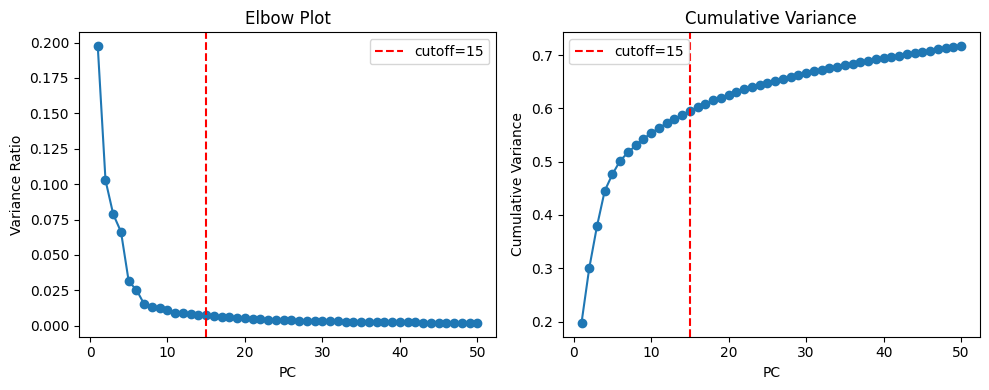

In [55]:
# Elbow plot to verify 15 PC cutoff
import matplotlib.pyplot as plt

variance_ratio = adata.uns['pca']['variance_ratio']
cumulative_var = np.cumsum(variance_ratio)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(range(1, 51), variance_ratio, 'o-')
axes[0].axvline(x=15, color='red', linestyle='--', label='cutoff=15')
axes[0].set_xlabel('PC')
axes[0].set_ylabel('Variance Ratio')
axes[0].set_title('Elbow Plot')
axes[0].legend()

axes[1].plot(range(1, 51), cumulative_var, 'o-')
axes[1].axvline(x=15, color='red', linestyle='--', label='cutoff=15')
axes[1].set_xlabel('PC')
axes[1].set_ylabel('Cumulative Variance')
axes[1].set_title('Cumulative Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

In [56]:
# Truncate to 15 PCs and run Harmony
adata.obsm['X_pca'] = adata.obsm['X_pca'][:, :15]

from scrna_benchmark.embedding import compute_harmony
compute_harmony(adata, batch_col="donor_id", basis="X_pca", key_added="X_harmony", n_comps=15)

print(f"X_pca:     {adata.obsm['X_pca'].shape}")
print(f"X_harmony: {adata.obsm['X_harmony'].shape}")

2026-05-30 14:50:50,830 - harmonypy - INFO - Running Harmony (PyTorch on mps)
2026-05-30 14:50:50,832 - harmonypy - INFO -   Parameters:
2026-05-30 14:50:50,832 - harmonypy - INFO -     max_iter_harmony: 10
2026-05-30 14:50:50,833 - harmonypy - INFO -     max_iter_kmeans: 20
2026-05-30 14:50:50,833 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-05-30 14:50:50,834 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-05-30 14:50:50,834 - harmonypy - INFO -     nclust: 100
2026-05-30 14:50:50,835 - harmonypy - INFO -     block_size: 0.05
2026-05-30 14:50:50,835 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
2026-05-30 14:50:50,835 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-05-30 14:50:50,836 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-05-30 14:50:50,836 - harmonypy - INFO -     verbose: True
2026-05-30 14:50:50,836 - harmonypy - INFO -     random_state: 0
2026-05-30 14:50:50,837 - 

X_pca:     (8500, 15)
X_harmony: (8500, 15)


In [57]:
# scVI — train on HVG raw counts
import scvi, scipy.sparse as sp

# Subset raw counts to HVG genes and add as layer
adata.layers["counts"] = counts_raw[:, hvg_mask]

scvi.settings.seed = 42
scvi.model.SCVI.setup_anndata(adata, layer="counts", batch_key="donor_id")
model = scvi.model.SCVI(adata, n_latent=15)
model.train(max_epochs=200, early_stopping=True)
adata.obsm["X_scVI"] = model.get_latent_representation()
print(f"X_scVI: {adata.obsm['X_scVI'].shape}")

Seed set to 42
/opt/anaconda3/envs/scanpy_pertpy/lib/python3.10/site-packages/scvi/train/_trainrunner.py:69: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/scanpy_pertpy/lib/python3.10/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/opt/anaconda3/envs/scanpy_pertpy/lib/python3.10/site-packages/lightning/pytorch/utilities/_

Epoch 200/200: 100%|██████████| 200/200 [02:19<00:00,  1.61it/s, v_num=1, train_loss_step=396, train_loss_epoch=395]

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 200/200: 100%|██████████| 200/200 [02:19<00:00,  1.43it/s, v_num=1, train_loss_step=396, train_loss_epoch=395]
X_scVI: (8500, 15)


In [58]:
# Final verification
print("=== Benchmark-Ready Object ===")
print(adata)
print(f"\n  X_pca:     {adata.obsm['X_pca'].shape}")
print(f"  X_harmony: {adata.obsm['X_harmony'].shape}")
print(f"  X_scVI:    {adata.obsm['X_scVI'].shape}")
print(f"\n  cell_type: {adata.obs['cell_type'].nunique()} types")
print(f"  donor_id:  {adata.obs['donor_id'].nunique()} donors")
print(f"  cells:     {adata.n_obs:,}")

=== Benchmark-Ready Object ===
AnnData object with n_obs × n_vars = 8500 × 1000
    obs: 'Annotated_Clusters', 'LibraryID', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'Seurat_Clusters', 'BMI', 'HbA1c', 'Islet', 'Center', 'Medication', 'Viability', 'Purity', 'Cause_of_death', 'Multiplex', 'BMI_Category', 'Clusters_DiseaseState', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'batch', 'sample_id', '_scvi_batch', '_scvi_labels'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_ty

In [59]:
# Save
out_path = Path("data/pancreas/pancreas_benchmark_ready.h5ad")
out_path.parent.mkdir(parents=True, exist_ok=True)
adata.write(out_path)
print(f"Saved: {out_path}  ({out_path.stat().st_size/1e6:.1f} MB)")

Saved: data/pancreas/pancreas_benchmark_ready.h5ad  (255.0 MB)
